In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df=pd.read_csv('IPL.csv')
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

In [ ]:
df.shape

(74, 20)

In [ ]:
df.isnull().sum()

,0
match_id,0
date,0
venue,0
team1,0
team2,0
stage,0
toss_winner,0
toss_decision,0
first_ings_score,0
first_ings_wkts,0


1.which team wom the most matchs ?


Text(0.5, 1.0, 'Teams with most wins')

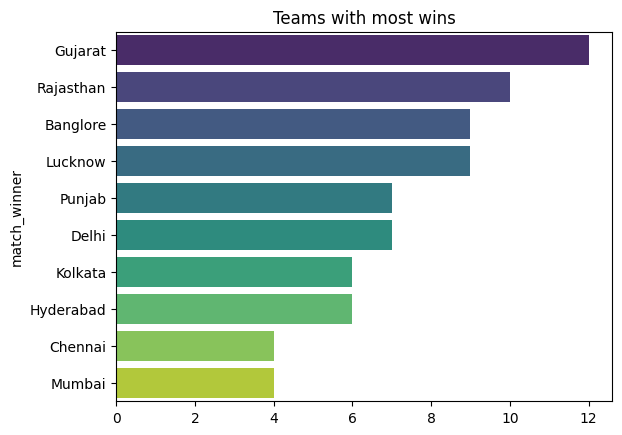

In [ ]:
match_wins=df['match_winner'].value_counts()
sns.barplot(y=match_wins.index,x=match_wins.values,palette='viridis')
plt.title('Teams with most wins')


2.Toss Decision Trends

Text(0.5, 1.0, 'Toss Decision Trends')

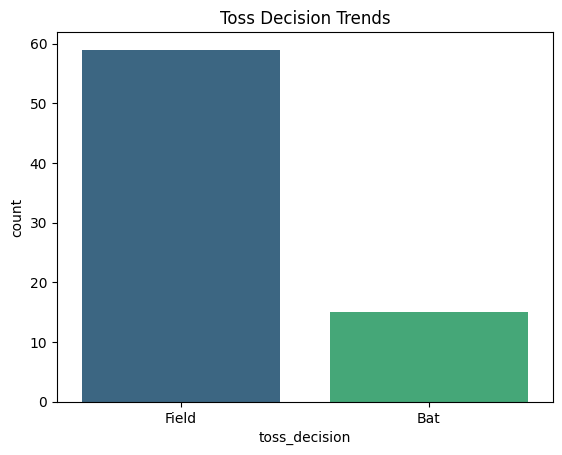

In [ ]:
sns.countplot(x=df['toss_decision'],palette='viridis')
plt.title('Toss Decision Trends')

3.Toss Winner vs Match Winner

In [ ]:
count=df[df['toss_winner']==df['match_winner']]['match_id'].count()
percentage=(count*100)/df.shape
percentage.round(2)


array([ 48.65, 180.  ])

4.How de teams win?(runs vs wickets)

Text(0.5, 1.0, 'How de teams win?')

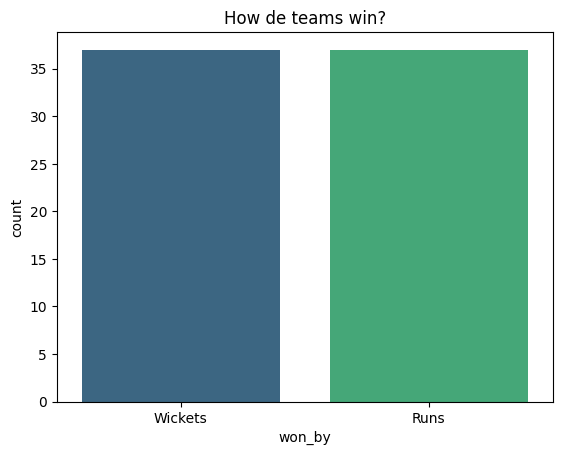

In [ ]:
sns.countplot(x=df['won_by'],palette='viridis')
plt.title('How de teams win?')

5. Most player of the match awards

Text(0.5, 1.0, 'Most player of the match awards')

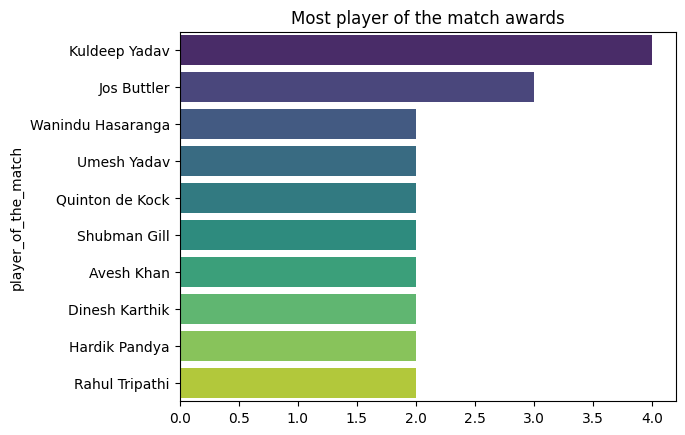

In [ ]:
count=df['player_of_the_match'].value_counts().head(10)
sns.barplot(y=count.index,x=count.values,palette='viridis')
plt.title('Most player of the match awards')

6.  2 top scorers


,highscore
top_scorer,
Jos Buttler,651
Quinton de Kock,377


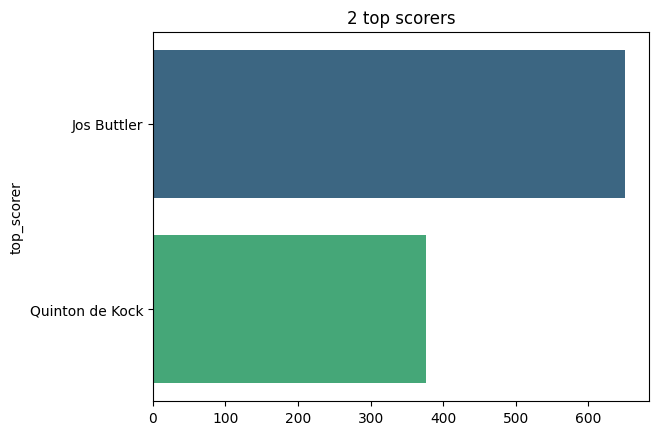

In [ ]:
high=df.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False).head(2)
sns.barplot(y=high.index,x=high.values,palette='viridis')
plt.title('2 top scorers')
high

7  best bolwing figurs

In [ ]:
df['highest_wickets']=df['best_bowling_figure'].apply(lambda x:x.split('--')[0])
df['highest_wickets']=df['highest_wickets'].astype(int)
top_bowler=df.groupby('best_bowling')['highest_wickets'].sum().sort_values(ascending=False)


,highest_wickets
best_bowling,
Yuzvendra Chahal,17
Jasprit Bumrah,11
Kuldeep Yadav,11
Rashid Khan,11
Josh Hazlewood,10
Kagiso Rabada,10
Avesh Khan,10
Umran Malik,9
Wanindu Hasaranga,9


Text(0.5, 1.0, 'best bolwing figurs')

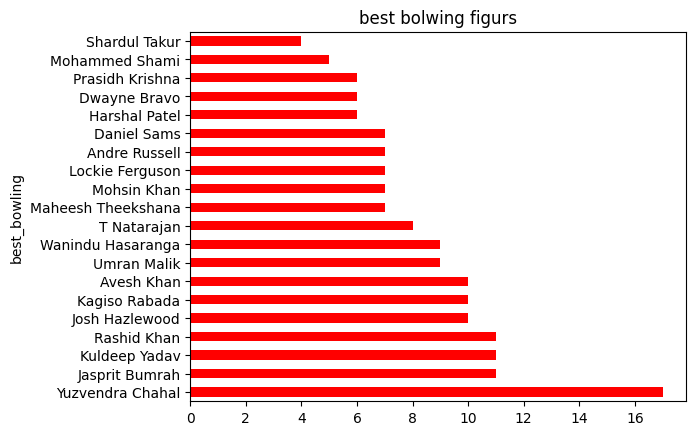

In [ ]:
df['highest_wickets']=df['best_bowling_figure'].apply(lambda x:x.split('--')[0])
df['highest_wickets']=df['highest_wickets'].astype(int)
top_bowler=df.groupby('best_bowling')['highest_wickets'].sum().sort_values(ascending=False).head(20)
top_bowler.plot(kind='barh',color='red')
plt.title('best bolwing figurs')

8  Most Match Played By Venue


In [ ]:
value_counts=df['venue'].value_counts()
value_counts

,count
venue,
"Wankhede Stadium, Mumbai",21
"Dr DY Patil Sports Academy, Mumbai",20
"Brabourne Stadium, Mumbai",16
"Maharashtra Cricket Association Stadium,Pune",13
"Eden Gardens, Kolkata",2
"Narendra Modi Stadium, Ahmedabad",2


Text(0.5, 1.0, 'Most Match Played By Venue')

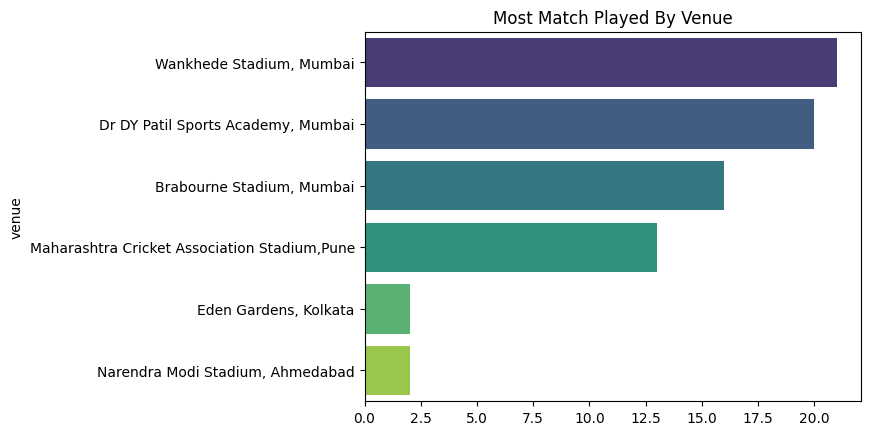

In [ ]:
sns.barplot(y=value_counts.index,x=value_counts.values,palette='viridis')
plt.title('Most Match Played By Venue')

9  who won the highest margin by the runs ?

In [ ]:
df[df['won_by']=='Runs'].sort_values(by='margin',ascending=False).head(1)[['match_winner','margin']]

,match_winner,margin
54,Chennai,91


10  which player had the highest individual score ?

In [ ]:
df[df['highscore'] == df['highscore'].max()][['top_scorer','highscore']]

,top_scorer,highscore
65,Quinton de Kock,140


11  which bowler had the best bowling figures?

In [ ]:
df[df['highest_wickets']==df['highest_wickets'].max()][['best_bowling','best_bowling_figure']]

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10
